##### Análise dados ENEM

   NU_INSCRICAO  NU_ANO  TP_FAIXA_ETARIA TP_SEXO  TP_ESTADO_CIVIL  \
0  210059085136    2023               14       M                2   
1  210059527735    2023               12       M                2   
2  210061103945    2023                6       F                1   
3  210060214087    2023                2       F                1   
4  210059980948    2023                3       F                1   

   TP_COR_RACA  TP_NACIONALIDADE  TP_ST_CONCLUSAO  TP_ANO_CONCLUIU  TP_ESCOLA  \
0            1                 1                1               17          1   
1            1                 0                1               16          1   
2            1                 1                1                0          1   
3            3                 1                2                0          2   
4            3                 1                2                0          2   

   ...  Q016  Q017  Q018 Q019  Q020 Q021  Q022  Q023  Q024  Q025  
0  ...     C     C     B    B  

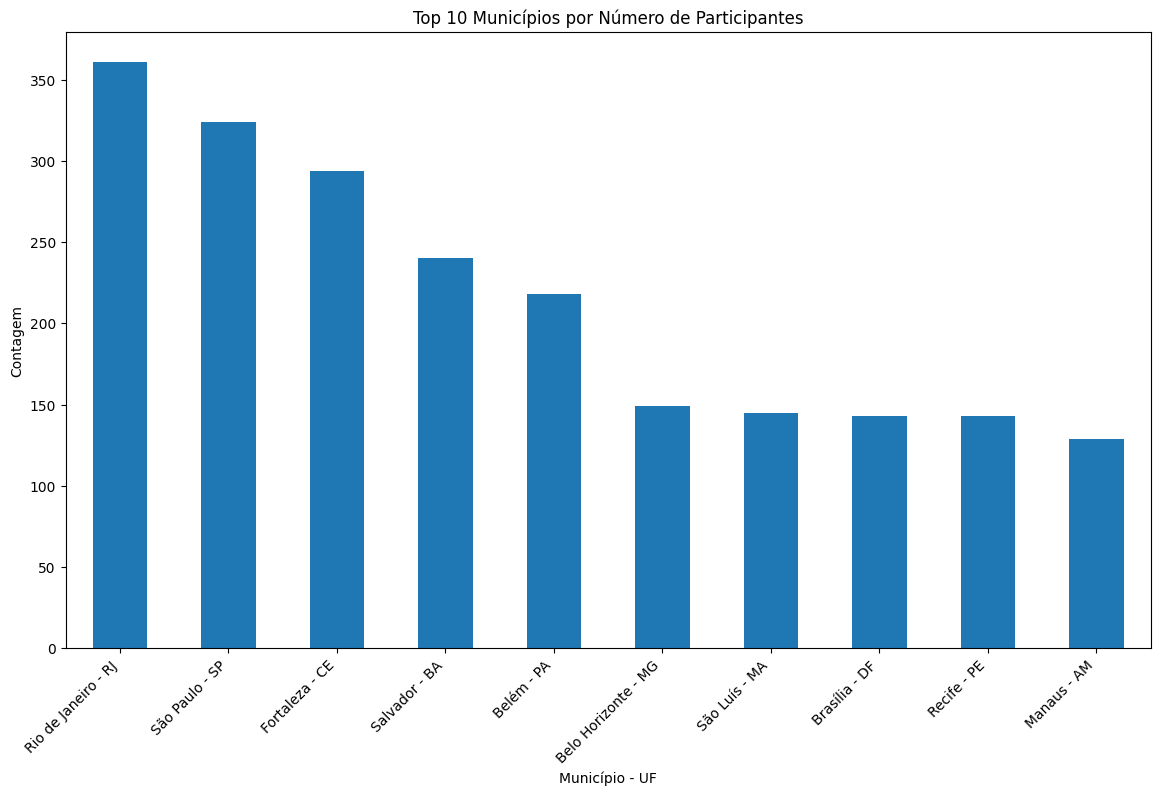

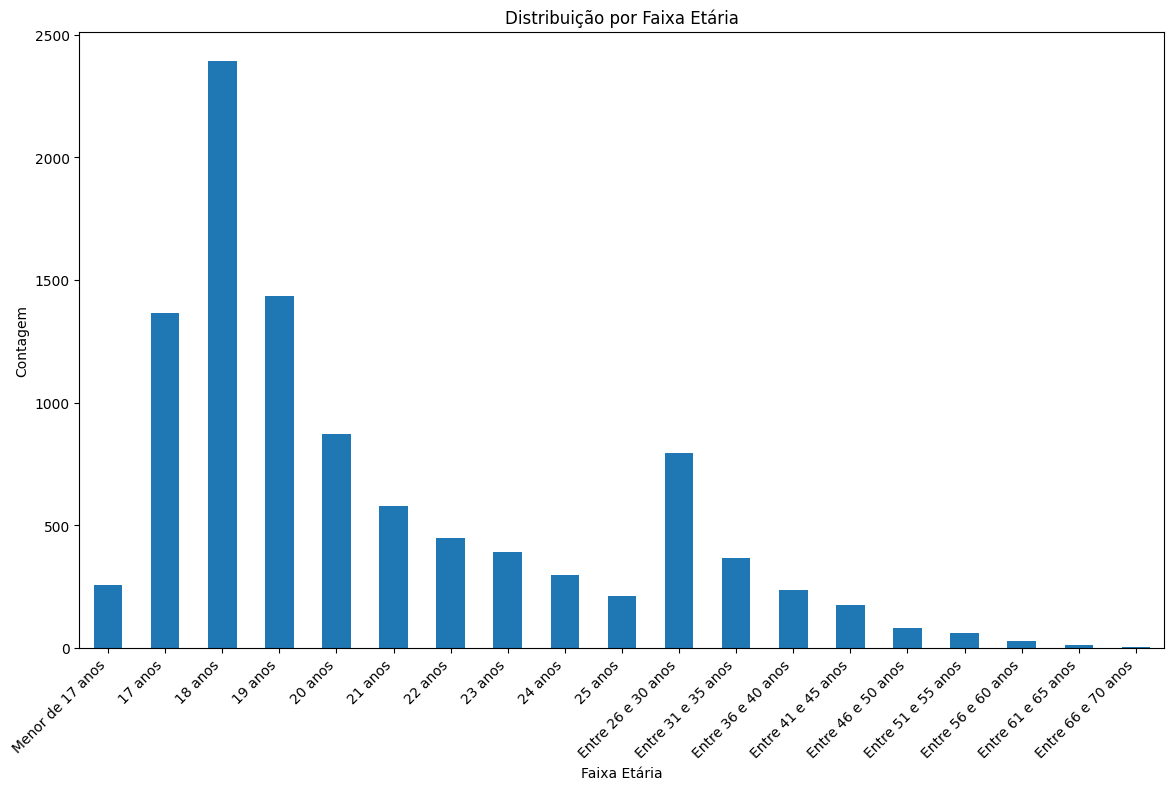

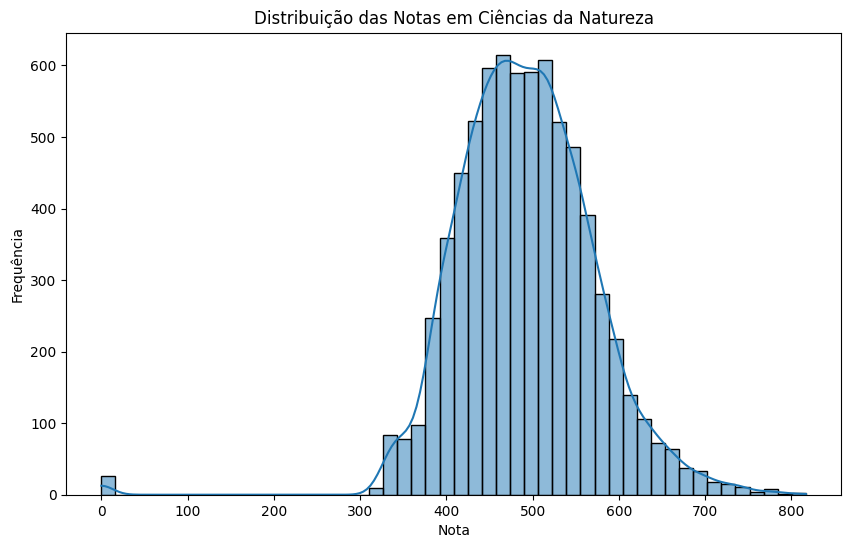

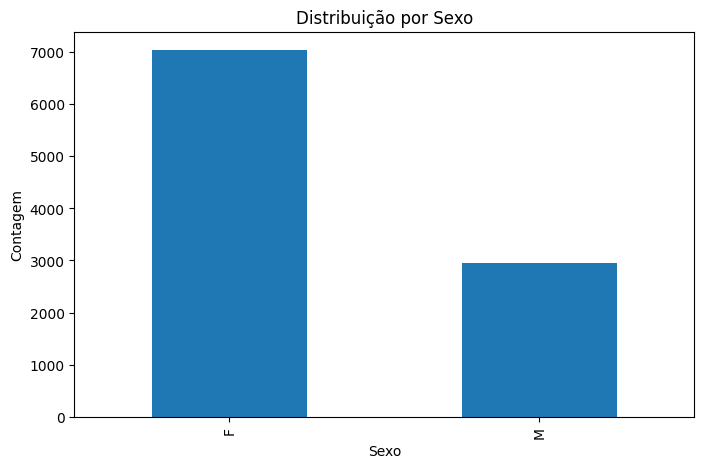

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o arquivo CSV com encoding adequado
df = pd.read_csv('DADOS/amostra.csv', encoding='latin1')

# Exibir as primeiras linhas
print(df.head())

# Criar nova coluna combinando NO_MUNICIPIO_PROVA e SG_UF_PROVA
if 'NO_MUNICIPIO_PROVA' in df.columns and 'SG_UF_PROVA' in df.columns:
    df['MUNICIPIO_UF'] = df['NO_MUNICIPIO_PROVA'] + ' - ' + df['SG_UF_PROVA']

# Exibir as primeiras linhas com a nova coluna
print(df[['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', 'MUNICIPIO_UF']].head())

# Gráfico para os top 10 municípios por contagem
if 'MUNICIPIO_UF' in df.columns:
    plt.figure(figsize=(14, 8))
    top_municipios = df['MUNICIPIO_UF'].value_counts().head(10)
    top_municipios.plot(kind='bar')
    plt.title('Top 10 Municípios por Número de Participantes')
    plt.xlabel('Município - UF')
    plt.ylabel('Contagem')
    plt.xticks(rotation=45, ha='right')
    plt.show()

# Mapeamento para TP_FAIXA_ETARIA
faixa_etaria_map = {
    1: 'Menor de 17 anos',
    2: '17 anos',
    3: '18 anos',
    4: '19 anos',
    5: '20 anos',
    6: '21 anos',
    7: '22 anos',
    8: '23 anos',
    9: '24 anos',
    10: '25 anos',
    11: 'Entre 26 e 30 anos',
    12: 'Entre 31 e 35 anos',
    13: 'Entre 36 e 40 anos',
    14: 'Entre 41 e 45 anos',
    15: 'Entre 46 e 50 anos',
    16: 'Entre 51 e 55 anos',
    17: 'Entre 56 e 60 anos',
    18: 'Entre 61 e 65 anos',
    19: 'Entre 66 e 70 anos',
    20: 'Maior de 70 anos'
}

# Gráfico para TP_FAIXA_ETARIA (Faixa Etária)
if 'TP_FAIXA_ETARIA' in df.columns:
    plt.figure(figsize=(14, 8))
    counts = df['TP_FAIXA_ETARIA'].value_counts().sort_index()
    counts.index = counts.index.map(faixa_etaria_map)
    counts.plot(kind='bar')
    plt.title('Distribuição por Faixa Etária')
    plt.xlabel('Faixa Etária')
    plt.ylabel('Contagem')
    plt.xticks(rotation=45, ha='right')
    plt.show()

# Exemplo de gráfico simples: histograma de uma coluna numérica
# Supondo que há uma coluna de notas, como 'NU_NOTA_CN'
if 'NU_NOTA_CN' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['NU_NOTA_CN'].dropna(), bins=50, kde=True)
    plt.title('Distribuição das Notas em Ciências da Natureza')
    plt.xlabel('Nota')
    plt.ylabel('Frequência')
    plt.show()

# Outro exemplo: gráfico de barras para uma coluna categórica
# Supondo 'TP_SEXO'
if 'TP_SEXO' in df.columns:
    plt.figure(figsize=(8, 5))
    df['TP_SEXO'].value_counts().plot(kind='bar')
    plt.title('Distribuição por Sexo')
    plt.xlabel('Sexo')
    plt.ylabel('Contagem')
    plt.show()